In [1]:
from typing import Annotated, List, TypedDict, Union, Optional, Literal, Dict, Any
from langchain_openai import ChatOpenAI
from langchain_chroma import Chroma
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, BaseMessage
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, END, START
from langgraph.prebuilt import ToolNode
from langgraph.graph.message import add_messages
from langchain_core.output_parsers import PydanticOutputParser
from pydantic import BaseModel, Field
import os, sys

c:\Users\user\potenup\ReNe\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, ".."))
sys.path.append(project_root)

In [3]:
company_id = 1
jobgroup_id = 1
jobseeker_id = 1

In [4]:
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
try:
    from src.core.database import SessionLocal
except ImportError:
    print("DB 모듈 임포트 실패: DB 저장 단계는 Mock으로 대체됩니다.")
    SessionLocal = None

print(f"Project Root added: {project_root}")

Project Root added: c:\Users\user\potenup\ReNe


### 그래프 상태 정의

In [6]:
# 그래프 상태 정의
class InterviewState(TypedDict):
    # 대화 기록 (Langraph가 자동으로 append 처리)
    messages: Annotated[List[BaseMessage], add_messages] # 대화 기록
    status: Literal["interview", "evaluate", "analyze", "done"]
    current_turn: int # 현재 턴수
    red_flag_count: int # 연속 실패 횟수(조기 종료용)

    # RAG 검색용 메타데이터
    jobseeker_id: int # 구직자 ID
    company_id: int # 기업 ID
    job_group_id: int # 직군 ID
    company_name: str
    jobseeker_name: str
    company_info: str # ChromaDB에서 가져온 기업 정보
    jobseeker_info: str # ChromaDB에서 가져온 구직자 정보
    resume_context: str
    portfolio_context: str
    company_introduction_context: str
    jd_context: str

    # 면접 단계용 필드
    interview_stage: str # "INTRO", "TECH", "BEHAVIORAL", "CLOSING"

    # 평가 데이터 (DB 저장용)
    evaluation_history: List[dict]

    # 최종 리포트 데이터 (Analyst 결과)
    final_result: Optional[dict] # Analyst 결과
    db_payload: Optional[dict] # DB 삽입용 정리된 데이터  


### 시스템 프롬프트 로딩 함수

In [7]:
def load_prompt_markdown(filename: str) -> str:
    """src/prompts 디렉토리에서 마크다운 프롬프트 파일을 읽어옵니다."""
    # 경로: ReNe/src/prompts/filename
    path = os.path.join(project_root, 'src', 'prompts', filename)
    try:
        with open(path, 'r', encoding='utf-8') as f:
            return f.read()
    except FileNotFoundError:
        print(f"프롬프트 파일을 찾을 수 없습니다.: {path}")

print(len(load_prompt_markdown("Corporate_Recruiter.md")))

 

1039


In [8]:
llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

### 필요한 정보 DB에서 추출

In [12]:
from src.repositories.resume_repository.resume_repository import ResumeRepository
from src.repositories.portfolio_repository.portfolio_repository import PortfolioRepository
from src.repositories.company_repository.company_repository import CompanyRepository
from src.repositories.recruitment_notice_repository.recruitment_notice_repository import RecruitmentNoticeRepository
from src.repositories.company_introduction_repository.company_introduction_repository import CompanyIntroductionRepository
from src.repositories.jobseeker_repository.jobseeker_repository import JobseekerRepository


In [ ]:
def initialize_node(state: InterviewState) -> Dict[str, Any]:
    print("--- [Initialize] 데이터 전체 로딩 ---")
    # 리포지토리에 의존성 주입
    company_repository = CompanyRepository(db=SessionLocal())
    jobseeker_repository = JobseekerRepository(db=SessionLocal())
    resume_repository = ResumeRepository(db=SessionLocal())
    portfolio_repository = PortfolioRepository(db=SessionLocal())
    company_introduction_repository = CompanyIntroductionRepository(db=SessionLocal())
    recruitment_notice_repository = RecruitmentNoticeRepository(db=SessionLocal())

    # DB에서 텍스트 전체를 가져옵니다.
    company_info = company_repository.get_info_as_markdown(state["company_id"])
    jobseeker_info = jobseeker_repository.get_info_as_markdown(state["jobseeker_id"])
    resume_text = resume_repository.get_full_text(state["jobseeker_id"])
    portfolio_text = portfolio_repository.get_full_text(state["jobseeker_id"])
    company_introduction = company_introduction_repository.get_full_text(state["company_id"])
    recruitment_notice = recruitment_notice_repository.get_full_text(state["job_group_id"])

    return {
        "company_info": company_info,
        "jobseeker_info": jobseeker_info,
        "resume_context": resume_text,
        "portfolio_context": portfolio_text,
        "company_introduction_context": company_introduction,
        "jd_context": recruitment_notice 
    }


In [16]:
def interviewer_node(state: InterviewState) -> Dict[str, Any]:
    print(f"\n [Interview] 질문 생성 중 (Turn: {state.get('current_turn', 0)}) ")
    """
    이전 평가 결과와 면접 진행 상황에 맞춰 다음 질문을 생성합니다.
    """
    system_prompt = load_prompt_markdown("company_ai_interview_prompt_ver2.0.md")

    current_turn = state.get("current_turn", 0)
    eval_history = state.get("evaluation_history", [])
    current_stage = state.get("interview_stage", "INTRO")

    if current_turn <= 1:
        current_stage = "INTRO"
    elif 1 < current_turn <= 4:
        current_stage = "RESUME_VERIFICATION" # 이력서 검증
    elif 4 < current_turn <= 7:
        current_stage = "TECH_SCREENING" # 기술 면접
    elif 7 < current_turn <= 10:
        current_stage = "CULTURE_FIT"
    elif current_turn > 10:
        current_stage = "CLOSING"
    
    # 직전 답변에 대한 반응 (압박 질문 여부
    last_eval = eval_history[-1]["eval"] if eval_history else {}
    guidance = ""
    if last_eval.get("follow_up_needed"):
        guidance = "!지침: 지원자의 이전 답변이 불충분합니다. 새로운 주제로 넘어가지 말고, 해당 내용을 구체적으로 파고드는 '압박 질문(Probing Question)'을 던지세요."
    else:
        guidance = "지침: 현재 스테이지[{current_stage}]에 알맞은 새로운 질문을 던지세요."

    
    # RAG용 정보 주입 (Initialize node 단계에서 로드된 정보를 사용)
    rag_context = f"""
    [기업 정보]
    {state.get('company_info', '정보 없음')}
    [기업 소개]
    {state.get('company_introduction_context', '정보 없음')}
    [기업 채용 공고]
    {state.get('recruitment_notice_context', '정보 없음')}
    [지원자 정보]
    {state.get('jobseeker_info', '정보없음')}
    [지원자 이력서]
    {state.get('resume_context', '정보없음')}
    [지원자 포트폴리오]
    {state.get('portfolio_context', '정보없음')}
    """
    prompt = ChatPromptTemplate.from_messages([
        ("system", system_prompt + "\n\n" + rag_context),
        ("system", f"현재 상황: {guidance}"),
        ("placeholder", "{messages}")
    ])

    chain = prompt | llm

    # 프롬프트에 파라미터 주입.
    response = chain.invoke({
        "company_name": state.get("company_name", "시프트업"),
        "user_name": state.get("jobseeker_name", "지원자"),
        "current_stage": current_stage,
        "last_evaluation_result": last_eval.get("result", "NONE"),
        "follow_up_needed": last_eval.get("follow_up_needed", False),
        "messages": state["messages"]   
    })
    
    return {
        "messages": [response],
        "current_turn": current_turn + 1,
        "interview_stage": current_stage
    }    


In [17]:
# 1. 원하는 출력 데이터 구조 정의 (Pydantic)
class EvaluationOutput(BaseModel):
    score: int = Field(description="0에서 10 사이의 정수 답변 점수")
    result: str = Field(description="평가 결과: PASS, WEAK, FAIL 중 하나")
    reason: str = Field(description="평가 근거 (한국어)")
    follow_up_needed: bool = Field(description="꼬리 질문 필요 여부 (True/False)")

def strict_evaluator_node(state: InterviewState) -> Dict[str, Any]:
    print(f"\n [Evaluator] 실전 평가 중 (Turn {state.get('current_turn')}) ")

    messages = state["messages"]
    if len(messages) < 2:
        return {"red_flag_count": 0}
    
    last_human_msg = state["messages"][-1].content
    last_ai_msg = state["messages"][-2].content

    evaluate_prompt = load_prompt_markdown("strict_evaluator.md")

    prompt = ChatPromptTemplate.from_messages([
        ("system", evaluate_prompt),
        ("system", "반드시 다음 형식 요구사항을 준수하여 JSON만 출력하세요:\n{format_instructions}"),
        ("human", f"질문: {last_ai_msg}\n답변: {last_human_msg}") 
    ])

    parser = PydanticOutputParser(pydantic_object=EvaluationOutput)

    chain = prompt | llm | parser

    try:
        eval_result = chain.invoke({
            "question_text":last_ai_msg,
            "answer_text": last_human_msg,
            "format_instructions": parser.get_format_instructions()
        })
        eval_result = eval_result.dict()

    except Exception as e:
        print(f"평가 결과 파싱 중 에러 발생: {e}")
        # 파싱 실패 시 안전 장치 (기본값)
        eval_result = {
            "score": 5, 
            "result": "WEAK", 
            "reason": "System Parsing Error", 
            "follow_up_needed": False
        }

    # 이후 로직은 동일
    score = eval_result.get("score", 5)
    result = eval_result.get("result", "WEAK")
    current_flag = state.get("red_flag_count", 0)

    if result == 'FAIL':
        new_current_flag =  current_flag + 1
        print(f"답변에서 결격 사유 감지. (연속 {new_current_flag}회)")
    else:
        new_current_flag = 0
        if result == "WEAK":
            print(f"[WEAK] 추가 검증 필요 (점수: {score}점) -> 레드 플래그 초기화됨")
        else:
            print(f"[PASS] 통과 (점수: {score}점) -> 레드 플래그 초기화됨")

    new_entry = {
        "turn": state.get("current_turn"),
        "stage": state.get("interview_stage", "UNKNOWN"),
        "question": last_ai_msg,
        "answer": last_human_msg,
        "eval": eval_result
    }

    return {
        "red_flag_count": new_current_flag,
        "evaluation_history": state.get("evaluation_history", []) + [new_entry]
    }
    


In [18]:
# 1. 스킬 상세 평가를 위한 서브 모델 정의
class SkillDetail(BaseModel):
    skill_name: str = Field(description="기술 스택 이름 (예: Python, AWS, 문제해결능력 등)")
    score: int = Field(description="기술 수준 등급 (1~8 사이의 정수)")
    reason: str = Field(description="해당 등급을 부여한 구체적인 평가 사유")

class FinalAnalystOutput(BaseModel):
    final_score: float = Field(description="종합 점수 (0-100)")
    interview_result: str = Field(description="PASS, HOLD, FAIL 중 하나")
    summary: str = Field(description="면접 한 줄 요약")
    detailed_report: str = Field(description="면접 상세 보고서")
    skills_evaluation: List[SkillDetail] = Field(description="검증된 기술들에 대한 상세 평가 리스트")
    best_answer: str = Field(description="면접자의 최고의 답변 내용 - 최고의 답변인 이유")
    worst_answer: str = Field(description="면접자의 최악의 답변 내용 - 최악의 답변인 이유")
    total_feedback_for_jobseeker: str = Field(description="지원자에게 줄 AI의 피드백")

def final_analyzer_node(state: InterviewState) -> Dict[str, Any]:
    print("\n [Analyze] 최종 분석 및 DB 저장 준비 중 ")

    transcript = "\n".join([f"{message.type}: {message.content}" for message in state["messages"]])

    # 파서 설정
    parser = PydanticOutputParser(pydantic_object=FinalAnalystOutput)
    # 페르소나 로드
    analyst_prompt = load_prompt_markdown("final_analyst.md")

    prompt = ChatPromptTemplate.from_messages([
        ("system", analyst_prompt),
        ("system", "반드시 다음 형식 요구사항을 준수하여 JSON만 출력하세요:\n{format_instructions}"),
        ("human", "전사본\n{full_transcript}")
    ])

    chain = prompt | llm | parser

    try:
        final_result = chain.invoke({
            "full_transcript": transcript,
            "company_name": state.get("company_name", ""),
            "jd_context": state.get("jd_context", ""),
            "format_instructions": parser.get_format_instructions()
        })
    except Exception as e:
        print(f"최종 분석 중 예외 발생: {e}")
        # 에러 발생 시 기본값
        final_result = {
            "final_score": 0.0,
            "interview_resul": "HOLD",
            "summary": "분석 오류",
            "detailed_report": "오류 발생",
            "skills_evaluation": [], # 빈 리스트
            "best_answer": "-",
            "worst_answer": "-",
            "total_feedback_for_jobseeker": "-"
        }

    # DB Payload 구성
    db_payload = {
        "jobseeker_id": state.get("jobseeker_id", 1),
        "job_group_id": state.get("job_group_id", 1),
        "report": final_result["detailed_report"],
        "summary": final_result["summary"],
        "total_score": final_result["final_score"],
        "ai_result": final_result["hiring_decision"],
        "best_answer": final_result["best_answer"],
        "worst_answer": final_result["worst_answer"],
        "total_advice": final_result["feedback_for_candidate"],
        
        # DB의 skills_evaluation 컬럼은 JSON 타입이므로 리스트(List[dict]) 그대로 저장하면 됩니다.
        "skills_evaluation": final_result["skills_evaluation"],
    }

    return {
        "final_result": final_result,
        "db_payload": db_payload 
    }

    

In [19]:
from src.repositories.company_ai_interview_repository.company_ai_interview_repository import CompanyAIInterviewRepository

In [20]:
def db_saver_node(state: InterviewState) -> Dict[str, Any]:
    print("\n [Save] DB 저장 중 ")

    db = SessionLocal()


    
    try:
        company_ai_interview_repository = CompanyAIInterviewRepository(db=db)
        saved_interview = company_ai_interview_repository.create(state.get("db_payload"))
        print(f"DB 저장 성공 (ID: {saved_interview.id})")
        
    except Exception as e:
        print(f"기업 AI DB 저장 실패: {e}")
    finally:
        db.close()

    return {"status": "done"}

In [21]:
# strict evaluator 가 끝난후 다음질문하러갈지 면접 종료 후 분석하러갈지 라우트 함수

from typing import Literal

def route_logic(state: InterviewState) -> Literal["interviewer_node", "final_analyzer_node"]:
    # 1. 강제 종료 시그널 확인
    if state.get("status") == "done":
        return "final_analyzer_node"

    # 2. Red Flag 3회 이상 누적 시 조기 종료 (광탈)
    if state.get("red_flag_count", 0) >= 3:
        print("결격 3회 누적 -> 면접이 조기 종료됩니다.")
        return "final_analyzer_node"

    if state.get("interview_stage") == "CLOSING":
        print("[System] 모든 면접 단계 종료 -> 최종 분석 이동")
        return "final_analyzer_node"
    
    return "interviewer_node"

In [22]:
# 그래프 연결
from langgraph.checkpoint.memory import MemorySaver

workflow = StateGraph(InterviewState)

# 노드 등록
workflow.add_node("initialize_node", initialize_node)
workflow.add_node("interviewer_node", interviewer_node)
workflow.add_node("strict_evaluator_node", strict_evaluator_node)
workflow.add_node("final_analyzer_node", final_analyzer_node)
workflow.add_node("db_saver_node", db_saver_node)

# 엣지 연결

# 1. 시작 -> 초기화 -> 첫 질문
workflow.set_entry_point("initialize_node")
workflow.add_edge("initialize_node", "interviewer_node")

# 2. 질문 --> (사용자 응답 대기) --> END
# API 서버에서는 여기서 멈추고 응답을 반환해야 하므로 END로 연결해야함
# 다음 턴은 사용자의 답변을 State에 추가한 후 'strict_evaluater_node'부터 시작하도록 해야함
workflow.add_edge("interviewer_node", END)

# 3. 평가자 -> (라우팅) -> 인터뷰어 OR 최종 분석가
workflow.add_conditional_edges(
    "strict_evaluator_node",
    route_logic,
    {
        "interviewer_node": "interviewer_node",
        "final_analyzer_node": "final_analyzer_node"
    }
)

# 4. 최종 분석가 -> DB 저장 -> 종료
workflow.add_edge("final_analyzer_node", "db_saver_node")
workflow.add_edge("db_saver_node", END)

# 컴파일
memory = MemorySaver()
graph = workflow.compile(checkpointer=memory)



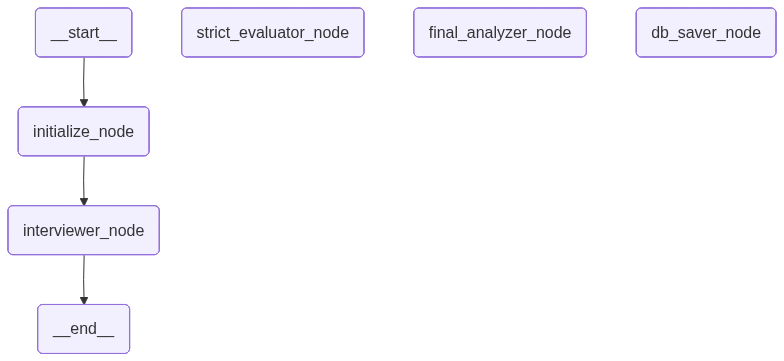

In [23]:
graph